# Summary Plots Barcharts

In [2]:
%%capture
# If getting 'Could not find project LASR_probe_gen' get key from https://wandb.ai/authorize and paste below
import os
os.environ["WANDB_SILENT"] = "true"
import wandb
wandb.login(key="2515140fe66df7aef4054b8a4200835635960747")

## Behaviour Plots

In [ ]:
from probe_gen.standard_experiments.behaviour_bar_plot import plot_behaviour_barchart
from probe_gen.config import BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL, BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION

# Define graph type
train_OOD = [False, True][0] # means test set wont match train set
test_incentivised = [False, True][0] # means we test against incentivised data

# Set probe type and activation model and keep all other parameters as initial experiments
probe_type = ["mean", "attention_torch"][0]
activations_model = ["llama_3b"][0] # currently the only option

done_experiments = BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL
if test_incentivised:
    done_experiments.update(BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION)
# Get experiments into format
# [probe_type, behaviour, [ID datasource, OOD datasource], activations_model, [ID off_policy_model, OOD off_policy_model]]
train_setup = []
for behaviour in list(done_experiments.keys()):
    ds = list(done_experiments[behaviour].keys())[1:]
    off_mods = [done_experiments[behaviour][ds[0]][activations_model], done_experiments[behaviour][ds[1]][activations_model]]
    train_setup.append([probe_type, behaviour, [ds[0], ds[1]], activations_model, [off_mods[0], off_mods[1]]])
    if done_experiments[behaviour]["test_both"]:
        train_setup.append([probe_type, behaviour, [ds[1], ds[0]], activations_model, [off_mods[1], off_mods[0]]])

plot_behaviour_barchart(
    train_setup=train_setup,
    train_OOD=train_OOD,
    test_incentivised=test_incentivised,
    add_mean_summary=False,
    save_path="linear_id_onpolicy.pdf",
    # save_path="linear_ood_onpolicy.pdf",
    # save_path="attention_id_onpolicy.pdf",
    # save_path="attention_ood_onpolicy.pdf",
    legend_loc="upper right",
    extra_whitespace=2,    
    # save_path="linear_id_incentivised.pdf",
    # # save_path="attention_id_incentivised.pdf",
    # legend_loc="lower left",
    # extra_whitespace=0,
    probe_type=probe_type,
)

## Mean Plots

In [ ]:
from probe_gen.standard_experiments.behaviour_bar_plot import plot_mean_summary_barchart
from probe_gen.config import BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL, BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION

# Define graph type
test_incentivised = [False, True][0] # means we test against incentivised data

# Set probe type and activation model and keep all other parameters as initial experiments
probe_type = ["mean", "attention_torch"][0]
activations_model = ["llama_3b"][0] # currently the only option

done_experiments = BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL
if test_incentivised:
    done_experiments.update(BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION)
# Get experiments into format
# [probe_type, behaviour, [ID datasource, OOD datasource], activations_model, [ID off_policy_model, OOD off_policy_model]]
train_setup = []
for behaviour in list(done_experiments.keys()):
    ds = list(done_experiments[behaviour].keys())[1:]
    off_mods = [done_experiments[behaviour][ds[0]][activations_model], done_experiments[behaviour][ds[1]][activations_model]]
    train_setup.append([probe_type, behaviour, [ds[0], ds[1]], activations_model, [off_mods[0], off_mods[1]]])
    if done_experiments[behaviour]["test_both"]:
        train_setup.append([probe_type, behaviour, [ds[1], ds[0]], activations_model, [off_mods[1], off_mods[0]]])

plot_mean_summary_barchart(
    train_setup=train_setup,
    test_incentivised=test_incentivised,
    save_path="linear_id_vs_ood_onpolicy.pdf",
    # save_path="attention_id_vs_ood_onpolicy.pdf",
    legend_loc="upper right",
    # legend_loc="lower left",
    extra_whitespace=0,
    probe_type=probe_type,
)

## Mean Plot Variations

In [1]:
from probe_gen.standard_experiments.behaviour_bar_plot import plot_mean_summary_barchart
from probe_gen.config import BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL, BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION

# Define graph type
test_incentivised = [False, True][0] # means we test against incentivised data

# Set probe type and activation model and keep all other parameters as initial experiments
probe_type = ["mean", "attention_torch"][0]
activations_model = ["llama_3b"][0] # currently the only option

done_experiments = BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL
if test_incentivised:
    done_experiments.update(BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION)
# Get experiments into format
# [probe_type, behaviour, [ID datasource, OOD datasource], activations_model, [ID off_policy_model, OOD off_policy_model]]
train_setup = []
for behaviour in list(done_experiments.keys()):
    ds = list(done_experiments[behaviour].keys())[1:]
    off_mods = [done_experiments[behaviour][ds[0]][activations_model], done_experiments[behaviour][ds[1]][activations_model]]
    train_setup.append([probe_type, behaviour, [ds[0], ds[1]], activations_model, [off_mods[0], off_mods[1]]])
    if done_experiments[behaviour]["test_both"]:
        train_setup.append([probe_type, behaviour, [ds[1], ds[0]], activations_model, [off_mods[1], off_mods[0]]])

# plot_mean_summary_barchart(
#     train_setup=train_setup,
#     test_incentivised=test_incentivised,
#     save_path="linear_id_vs_ood_onpolicy.pdf",
#     # save_path="attention_id_vs_ood_onpolicy.pdf",
#     legend_loc="upper right",
#     # legend_loc="lower left",
#     extra_whitespace=0,
#     probe_type=probe_type,
# )

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from probe_gen.standard_experiments.behaviour_bar_plot import get_bar_chart_results_table_from_wandb

train_setup
test_incentivised=False
title=None
xlabel=None
ylabel="Test AUROC"
save_path=None
figsize=(7, 4)
dpi=300
legend_loc="upper right"
extra_whitespace=0

if test_incentivised:
    group_labels =  ['On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
    train_gen_methods = ['incentivised', 'prompted', 'off_policy']
    test_gen_method = 'incentivised'
else:
    group_labels =  ['On-Policy Natural', 'On-Policy Incentivised', 'On-Policy Prompted', 'Off-Policy']
    train_gen_methods = ['on_policy', 'incentivised', 'prompted', 'off_policy']
    test_gen_method = 'on_policy'

train_colors = ['#264653', '#2A9D8F', '#E76F51', '#F18F01'] if not test_incentivised else ['#2A9D8F', '#E76F51', '#F18F01']

# Fetch data
print("Fetching results...")
results_same = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods, test_gen_method, train_OOD=False)
results_diff = get_bar_chart_results_table_from_wandb(train_setup, train_gen_methods, test_gen_method, train_OOD=True)
print("Fetched")

# Ensure arrays are numpy arrays of float and use np.nan for missing if needed
results_same = np.array(results_same, dtype=float)
results_diff = np.array(results_diff, dtype=float)

# If your missing values are represented by 0 (as before), convert them to np.nan so plotting skips them:
results_same[results_same == 0] = np.nan
results_diff[results_diff == 0] = np.nan

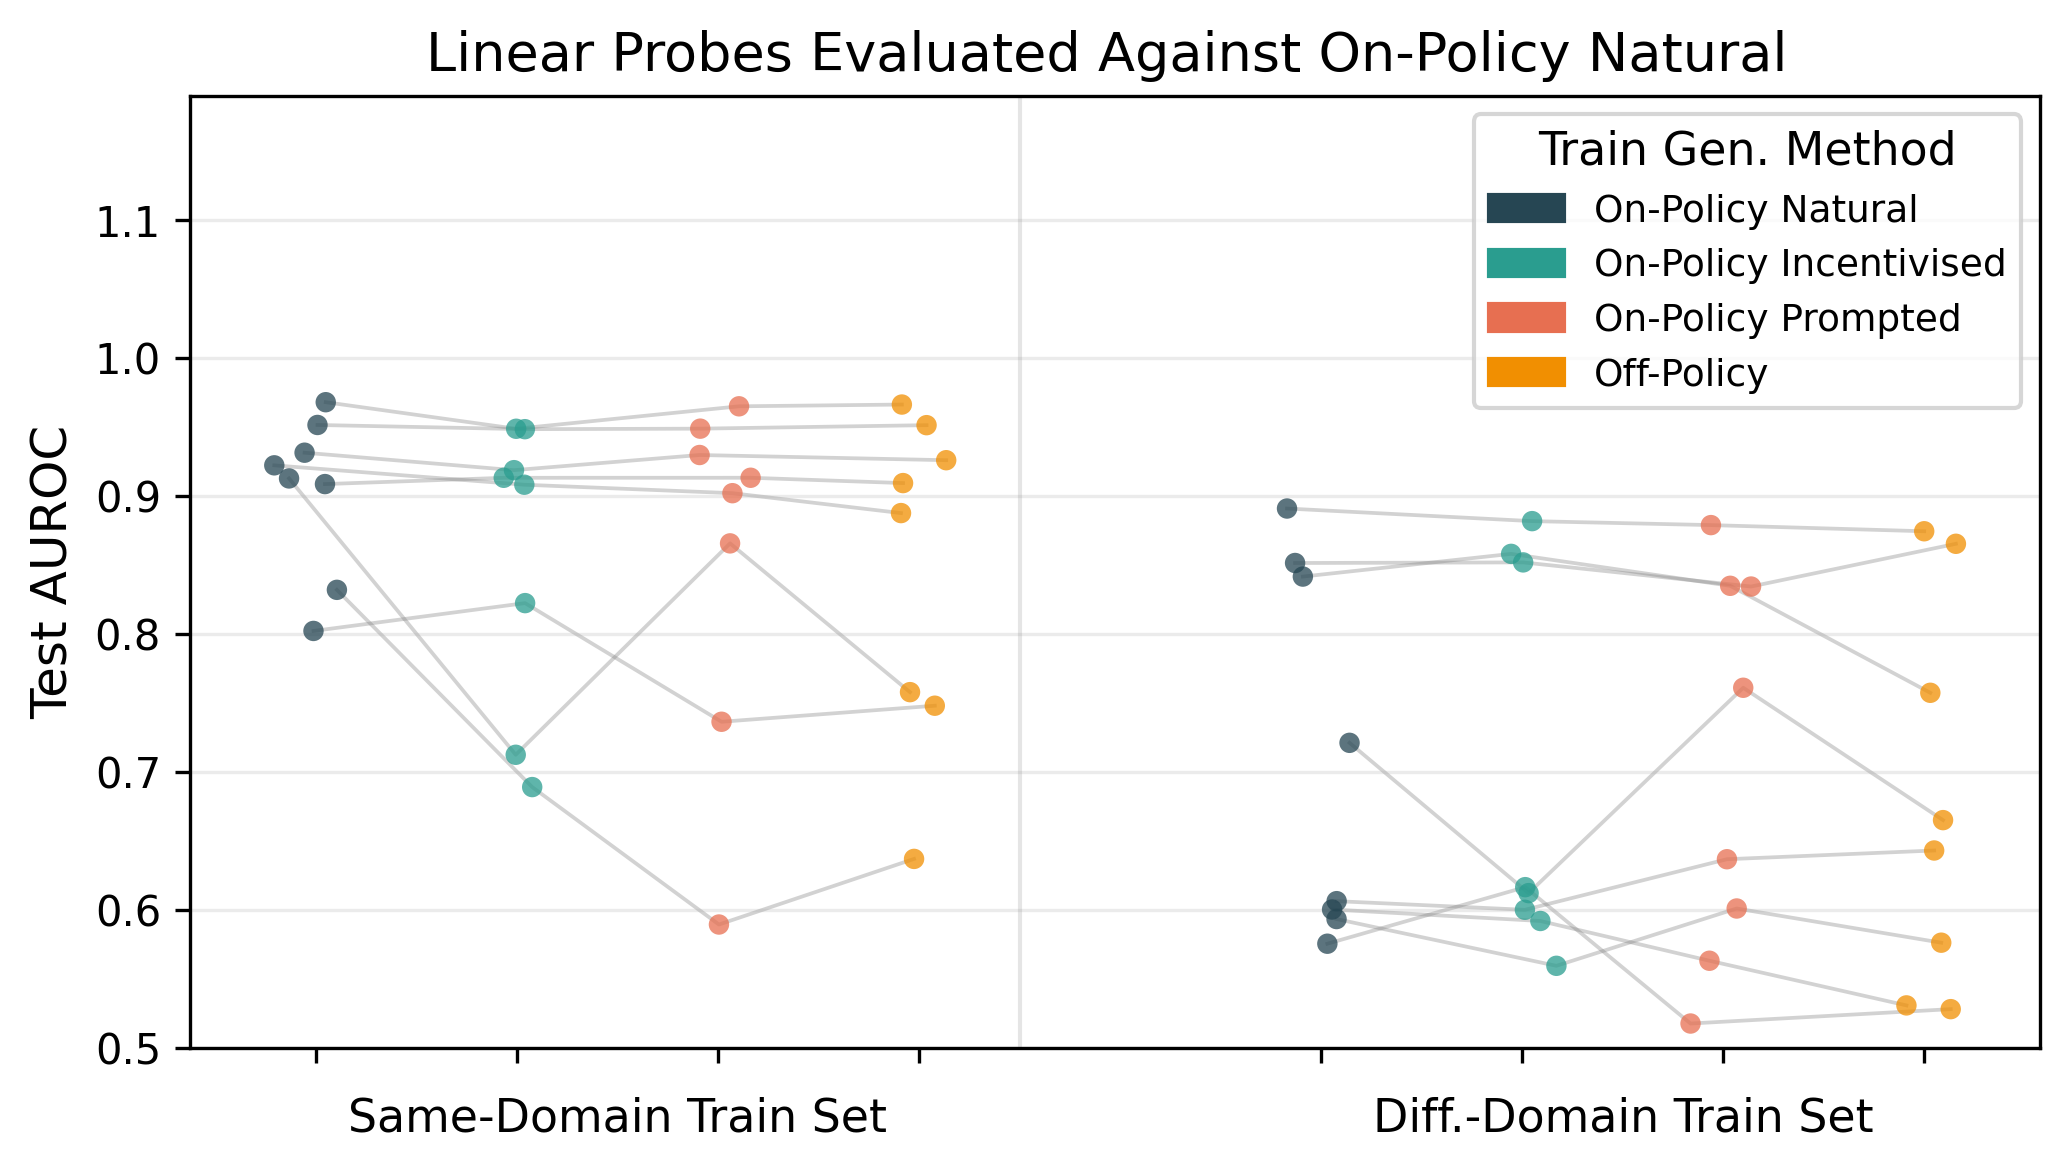

In [26]:
import matplotlib.patches as mpatches

title=None
xlabel=None
ylabel="Test AUROC"
figsize=(7, 4)
dpi=300
save_path=None
jitter=0.08
alpha_dots=0.75
alpha_lines=0.35


num_policies, n_cases = results_same.shape
assert results_diff.shape == (num_policies, n_cases)

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

# Pre-generate a jitter offset matrix so dots + lines share it
jitter_same = np.random.normal(0, jitter, size=(num_policies, n_cases))
jitter_diff = np.random.normal(0, jitter, size=(num_policies, n_cases))

# X positions
x_positions_same = np.arange(num_policies)
x_positions_diff = x_positions_same + num_policies + 1  # +1 gap between groups

# --- SAME-DOMAIN group ---
for j in range(n_cases):
    y_vals = results_same[:, j]
    valid = (y_vals != 0) & ~np.isnan(y_vals)
    if np.any(valid):
        xs = x_positions_same[valid] + jitter_same[valid, j]
        ax.plot(xs, y_vals[valid],
                color="gray", alpha=alpha_lines, linewidth=0.9, zorder=1)

# Scatter dots
for i in range(num_policies):
    color = train_colors[i % len(train_colors)]
    y_vals = results_same[i, :]
    valid = (y_vals != 0) & ~np.isnan(y_vals)
    xs = x_positions_same[i] + jitter_same[i, valid]
    ax.scatter(xs, y_vals[valid], color=color, alpha=alpha_dots, s=24, edgecolors='none', zorder=2)

# --- DIFF-DOMAIN group ---
for j in range(n_cases):
    y_vals = results_diff[:, j]
    valid = (y_vals != 0) & ~np.isnan(y_vals)
    if np.any(valid):
        xs = x_positions_diff[valid] + jitter_diff[valid, j]
        ax.plot(xs, y_vals[valid],
                color="gray", alpha=alpha_lines, linewidth=0.9, zorder=1)

for i in range(num_policies):
    color = train_colors[i % len(train_colors)]
    y_vals = results_diff[i, :]
    valid = (y_vals != 0) & ~np.isnan(y_vals)
    xs = x_positions_diff[i] + jitter_diff[i, valid]
    ax.scatter(xs, y_vals[valid], color=color, alpha=alpha_dots, s=24, edgecolors='none', zorder=2)

# --- Formatting ---
ax.axvline(x=num_policies - 0.5, color="gray", alpha=0.2, linewidth=1)

patches = [mpatches.Patch(color=train_colors[i], label=group_labels[i]) for i in range(num_policies)]
ax.legend(handles=patches, title="Train Gen. Method", loc="upper right", fontsize=9, title_fontsize=11)

# Keep ticks (for correct alignment) but hide their labels
ax.set_xticks(list(x_positions_same) + list(x_positions_diff))
ax.set_xticklabels([""] * (len(x_positions_same) + len(x_positions_diff)))

# Add centered group labels below
mid_same = np.mean(x_positions_same)
mid_diff = np.mean(x_positions_diff)
ax.text(mid_same, ax.get_ylim()[0] - 0.03, "Same-Domain Train Set", ha="center", va="top", fontsize=11)
ax.text(mid_diff, ax.get_ylim()[0] - 0.03, "Diff.-Domain Train Set", ha="center", va="top", fontsize=11)


title = f"{'Linear' if probe_type == 'mean' else 'Attention'} Probes Evaluated Against On-Policy {'Incentivised ' if test_incentivised else 'Natural '}"
ax.set_title(title)

ax.set_ylabel(ylabel)
if xlabel:
    ax.set_xlabel(xlabel)
if title:
    ax.set_title(title)
ax.grid(True, axis='y', alpha=0.25)
ax.set_ylim(0.5, 1.19)

ax.title.set_fontsize(13)     # change font size separately
ax.xaxis.label.set_size(12)   # x-axis label font size
ax.yaxis.label.set_size(12)   # y-axis label font size

plt.tight_layout()
if save_path:
    plt.savefig(save_path, dpi=dpi)
plt.show()


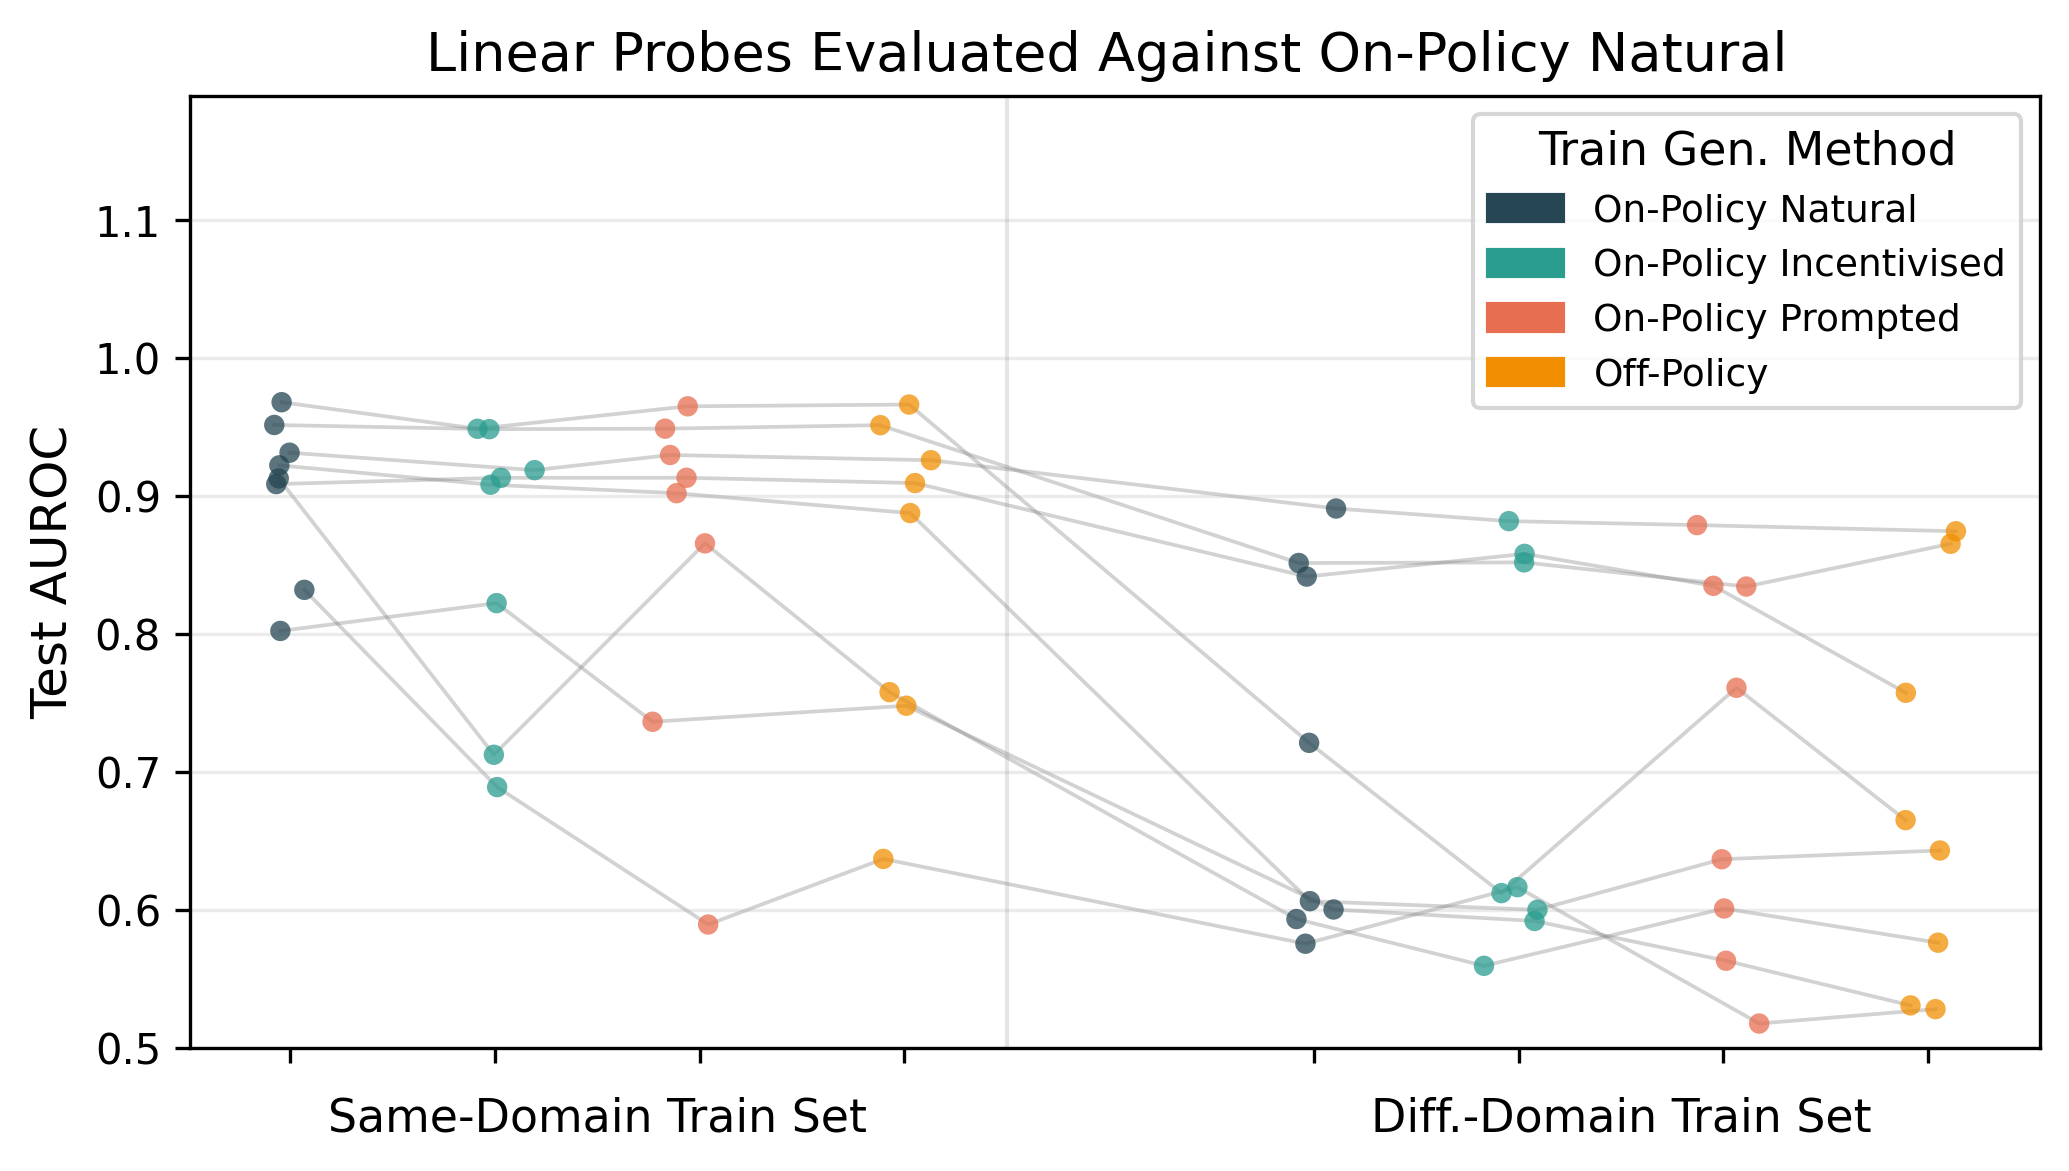

In [27]:
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import textwrap

title=None
xlabel=None
ylabel="Test AUROC"
figsize=(7, 4)
dpi=300
save_path=None
jitter=0.08
alpha_dots=0.75
alpha_lines=0.35

num_policies, n_cases = results_same.shape
assert results_diff.shape == (num_policies, n_cases)

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

# Pre-generate jitter offsets (same jittering logic across domains)
jitter_same = np.random.normal(0, jitter, size=(num_policies, n_cases))
jitter_diff = np.random.normal(0, jitter, size=(num_policies, n_cases))

# X positions
x_positions_same = np.arange(num_policies)
x_positions_diff = x_positions_same + num_policies + 1  # +1 gap between groups

# --- CONTINUOUS CONNECTED LINES ACROSS DOMAINS ---
for j in range(n_cases):
    y_same = results_same[:, j]
    y_diff = results_diff[:, j]

    # Combine y-values (ignore missing)
    y_combined = np.concatenate([y_same, y_diff])
    valid = (y_combined != 0) & ~np.isnan(y_combined)
    if np.any(valid):
        xs_same = x_positions_same + jitter_same[:, j]
        xs_diff = x_positions_diff + jitter_diff[:, j]
        xs_combined = np.concatenate([xs_same, xs_diff])
        ax.plot(xs_combined[valid], y_combined[valid],
                color="gray", alpha=alpha_lines, linewidth=0.9, zorder=1)

# --- DOTS (Same-domain) ---
for i in range(num_policies):
    color = train_colors[i % len(train_colors)]
    y_vals = results_same[i, :]
    valid = (y_vals != 0) & ~np.isnan(y_vals)
    xs = x_positions_same[i] + jitter_same[i, valid]
    ax.scatter(xs, y_vals[valid], color=color, alpha=alpha_dots, s=24, edgecolors='none', zorder=2)

# --- DOTS (Diff-domain) ---
for i in range(num_policies):
    color = train_colors[i % len(train_colors)]
    y_vals = results_diff[i, :]
    valid = (y_vals != 0) & ~np.isnan(y_vals)
    xs = x_positions_diff[i] + jitter_diff[i, valid]
    ax.scatter(xs, y_vals[valid], color=color, alpha=alpha_dots, s=24, edgecolors='none', zorder=2)

# --- Formatting ---
ax.axvline(x=num_policies - 0.5, color="gray", alpha=0.2, linewidth=1)

# Legend
patches = [mpatches.Patch(color=train_colors[i], label=group_labels[i]) for i in range(num_policies)]
ax.legend(handles=patches, title="Train Gen. Method", loc="upper right", fontsize=9, title_fontsize=11)

# Tick positions (hidden labels)
ax.set_xticks(list(x_positions_same) + list(x_positions_diff))
ax.set_xticklabels([""] * (len(x_positions_same) + len(x_positions_diff)))

# Add centered domain labels
mid_same = np.mean(x_positions_same)
mid_diff = np.mean(x_positions_diff)
ax.text(mid_same, ax.get_ylim()[0] - 0.03, "Same-Domain Train Set", ha="center", va="top", fontsize=11)
ax.text(mid_diff, ax.get_ylim()[0] - 0.03, "Diff.-Domain Train Set", ha="center", va="top", fontsize=11)

# Titles and labels
title = f"{'Linear' if probe_type == 'mean' else 'Attention'} Probes Evaluated Against On-Policy {'Incentivised ' if test_incentivised else 'Natural '}"
ax.set_title(title)

ax.set_ylabel(ylabel)
if xlabel:
    ax.set_xlabel(xlabel)
ax.grid(True, axis='y', alpha=0.25)
ax.set_ylim(0.5, 1.19)

ax.title.set_fontsize(13)
ax.xaxis.label.set_size(12)
ax.yaxis.label.set_size(12)

plt.tight_layout()
if save_path:
    plt.savefig(save_path, dpi=dpi)
plt.show()
